
---

# 🚀 Case Study: Customer Segmentation + Churn Prediction + Next-Month Spend Forecast

## 🏢 Business Context

An e-commerce subscription company wants to leverage data science to drive smarter business decisions. The objectives are:

1. 🎯 **Customer Segmentation** — Group customers into behavior-based clusters for targeted marketing campaigns
2. ⚠️ **Churn Prediction** — Identify customers likely to leave so the retention team can proactively intervene
3. 💰 **Next-Month Spend Forecasting** — Predict upcoming customer spend to optimize revenue planning and personalized offers

---

## 📊 Why This Matters

* 🔁 **Retention > Acquisition** — Keeping customers is significantly more cost-effective than acquiring new ones.
* 🧠 **Smarter Targeting** — Segmentation prevents one-size-fits-all marketing strategies.
* 📈 **Revenue Optimization** — Spend forecasting enables better promotion allocation and budget planning.
* 🎁 **Personalization at Scale** — Data-driven insights improve customer experience and lifetime value.

---

## 🛠️ Technical Approach & Deliverables

### 🔹 1. Customer Segmentation

* KMeans Clustering
* PCA for dimensionality reduction and visualization
* Behavioral feature engineering

### 🔹 2. Churn Prediction

* Logistic Regression (baseline, interpretable model)
* Random Forest (non-linear, performance-driven model)
* Model evaluation using ROC-AUC, Precision-Recall, and Confusion Matrix

### 🔹 3. Next-Month Spend Forecasting

* Regression modeling (Linear Regression + Tree-based methods)
* Feature importance analysis
* Revenue impact estimation

---

## 🎯 Business Impact

* Data-driven customer targeting
* Proactive churn mitigation strategy
* Revenue forecasting with actionable insights
* Clear recommendations for marketing and retention teams

---



In [ ]:
# =========================
# 0) SETUP
# =========================
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

np.random.seed(42)

print("Libraries loaded ✅")


Libraries loaded ✅



---

## 🧠 Data Strategy (Simulation for Learning)

In a real-world production environment, data would be sourced from multiple structured and semi-structured systems, including:

* 👤 **Customer Profile Table**
  Demographics and account-level attributes such as country, age, income, and tenure

* 📱 **Web / App Analytics Logs**
  Behavioral metrics including monthly visits, session frequency, and engagement signals

* 🛒 **Transaction Logs**
  Order history, purchase amounts, discount usage, and payment activity

* 🔄 **Churn Label**
  Subscription status indicating canceled accounts or prolonged inactivity

---

## 🧪 Why We Use Simulated Data

Since real company data is confidential and not publicly accessible, this project uses **synthetic data with realistic behavioral patterns** to replicate production-level workflows.

✔️ Preserves the **end-to-end data science pipeline**
✔️ Enables feature engineering, modeling, and evaluation
✔️ Mimics real-world business distributions (churn behavior, spending patterns, engagement trends)
✔️ Allows experimentation without privacy or compliance risks

---

## ⚙️ Key Principle

Although the dataset is simulated, the **methodology, modeling techniques, validation strategy, and business interpretation remain identical to a real enterprise data science project.**

This ensures the learning experience reflects industry-grade analytics practices while maintaining full data privacy.

---


In [ ]:
# =========================
# 1) GENERATE CUSTOMER DATA
# =========================
n_customers = 5000

customers = pd.DataFrame({
    "customer_id": range(1, n_customers + 1),
    "country": np.random.choice(["US", "UK"], size=n_customers, p=[0.6, 0.4]),
    "age": np.random.randint(18, 70, size=n_customers),
    "income": np.random.normal(60000, 20000, size=n_customers).round(0),
    "tenure": np.random.randint(1, 60, size=n_customers),           # months
    "visits_per_month": np.random.poisson(6, size=n_customers)
})

# Guardrails: income should not go negative
customers["income"] = customers["income"].clip(lower=5000)

customers.head()


,customer_id,country,age,income,tenure,visits_per_month
0,1,US,68,59733.0,40,4
1,2,UK,57,53146.0,21,8
2,3,UK,24,48007.0,46,2
3,4,US,49,20719.0,48,2
4,5,US,65,25343.0,38,5




---

### ✅ 1) Set the dataset size
```python
n_customers = 5000
````

* **What it does:** Decides how many customers (rows) you want.
* **Intuition:** More rows → more stable statistics (means, correlations, model training).

---

### ✅ 2) Build a DataFrame of synthetic customers

```python
customers = pd.DataFrame({
```

* **What it does:** Creates a `pandas` table (DataFrame).
* **Intuition:** Each key becomes a **column name**, each value becomes the **column data**.

---

### 🆔 `customer_id` — unique identifier

```python
"customer_id": range(1, n_customers + 1),
```

* **What it does:** Creates IDs from `1` to `5000`.
* **Why:** IDs help with joins/merges and tracking customers.
* **Stats note:** This is an **identifier**, not a feature you usually model directly.

---

### 🌍 `country` — categorical with probabilities

```python
"country": np.random.choice(["US", "UK"], size=n_customers, p=[0.6, 0.4]),
```

* **What it does:** Randomly assigns each customer to **US or UK**.
* **Key arguments:**

  * `["US","UK"]` → possible categories
  * `size=n_customers` → generate one value per customer
  * `p=[0.6,0.4]` → **60% US**, **40% UK**
* **Intuition:** This simulates an imbalanced market (more US customers).
* **Stats note:** This is like sampling from a **Categorical distribution**.

---

### 🎂 `age` — integer uniform-ish range

```python
"age": np.random.randint(18, 70, size=n_customers),
```

* **What it does:** Generates **integer ages** from **18 to 69**.
* **Important detail:** `randint(low, high)` is **inclusive of low**, **exclusive of high**.

  * So this gives 18 ≤ age < 70.
* **Intuition:** Simple baseline demographic generation.
* **Stats note:** This is a **discrete uniform** distribution across the range.

---

### 💰 `income` — continuous normal distribution

```python
"income": np.random.normal(60000, 20000, size=n_customers).round(0),
```

* **What it does:** Generates income from a **Normal distribution**:

  * mean (μ) = **60,000**
  * standard deviation (σ) = **20,000**
* **Why Normal?** Many real-world numeric variables are roughly bell-shaped (not perfect, but useful).
* **`.round(0)`**: rounds to the nearest dollar (still stored as float unless cast to int).
* **Stats intuition:**

  * ~68% of values fall within μ ± σ → between **40k and 80k**
  * ~95% within μ ± 2σ → between **20k and 100k**

---

### ⏳ `tenure` — months with integer range

```python
"tenure": np.random.randint(1, 60, size=n_customers),           # months
```

* **What it does:** Generates tenure (how long they've been a customer) in months: **1 to 59**.
* **Why:** Tenure is often a strong predictor of churn and engagement.
* **Comment `# months`:** Documentation for humans (no effect on code).

---

### 🧭 `visits_per_month` — count data using Poisson

```python
"visits_per_month": np.random.poisson(6, size=n_customers)
```

* **What it does:** Generates monthly visit counts from a **Poisson distribution** with λ = 6.
* **Why Poisson?** It’s a standard model for **counts** (events per time period).
* **Intuition:** Most customers will be near **6 visits**, with some lower/higher naturally.

---

### ✅ 3) Close the DataFrame constructor

```python
})
```

* **What it does:** Ends the dictionary and finishes creating the DataFrame.

---

### 🛡️ 4) Guardrail: prevent impossible negative income

```python
customers["income"] = customers["income"].clip(lower=5000)
```

* **Problem:** Normal distributions can produce unrealistic values like **negative income**.
* **Solution:** `clip(lower=5000)` forces:

  * any income < 5000 becomes **5000**
* **Data science note:** This is a basic **data validation / constraint** step (very common in synthetic data generation).

---

### 👀 5) Preview the first few rows

```python
customers.head()
```

* **What it does:** Displays the **first 5 rows** of the DataFrame.
* **Why:** Quick sanity check that columns look correct.

---

## 🧠 Mini summary (what distributions you used)

* **country:** Categorical (US/UK) with probabilities ✅
* **age:** Discrete uniform integers ✅
* **income:** Normal (Gaussian) + guardrail ✅
* **tenure:** Discrete uniform integers ✅
* **visits_per_month:** Poisson count model ✅

---





---

## 🔎 Quick EDA (Sanity Checks)

Before modeling, we perform lightweight exploratory analysis to validate data quality and realism.

### ✅ What We Validate

* 📊 **Distribution Checks**
  Ensure numerical features (age, income, spend, visits) follow realistic business patterns

* 🚫 **Impossible Value Detection**
  No negative ages, invalid income ranges, unrealistic transaction amounts, or invalid tenure

* 📈 **Basic Summary Statistics**
  Mean, median, standard deviation, min/max validation for logical consistency

---

## 🧪 Why This Step Matters

Even in simulated environments, performing structured EDA ensures:

✔️ Features behave as expected
✔️ Target variables are reasonable
✔️ Models won’t learn from corrupted data
✔️ Downstream results are trustworthy

---

> 🏢 **Case Study Note:**
> In a real production setting, we would additionally evaluate:
>
> * Missingness patterns (MCAR/MAR/MNAR considerations)
> * Outlier detection and treatment
> * Class imbalance severity
> * Potential data leakage across time
> * Feature drift and data stability checks

---

This keeps the workflow aligned with **industry-standard data validation practices** before moving into modeling.



In [ ]:
customers.describe(include="all")


,customer_id,country,age,income,tenure,visits_per_month
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000
unique,NaN,2,NaN,NaN,NaN,NaN
top,NaN,US,NaN,NaN,NaN,NaN
freq,NaN,2999,NaN,NaN,NaN,NaN
mean,2500.500000,NaN,43.187800,59775.435000,29.897800,6.027200
std,1443.520003,NaN,14.941472,20070.274685,17.054604,2.416201
min,1.000000,NaN,18.000000,5000.000000,1.000000,0.000000
25%,1250.750000,NaN,30.000000,46128.000000,15.000000,4.000000
50%,2500.500000,NaN,43.000000,59603.000000,30.000000,6.000000
75%,3750.250000,NaN,56.000000,73196.750000,45.000000,8.000000


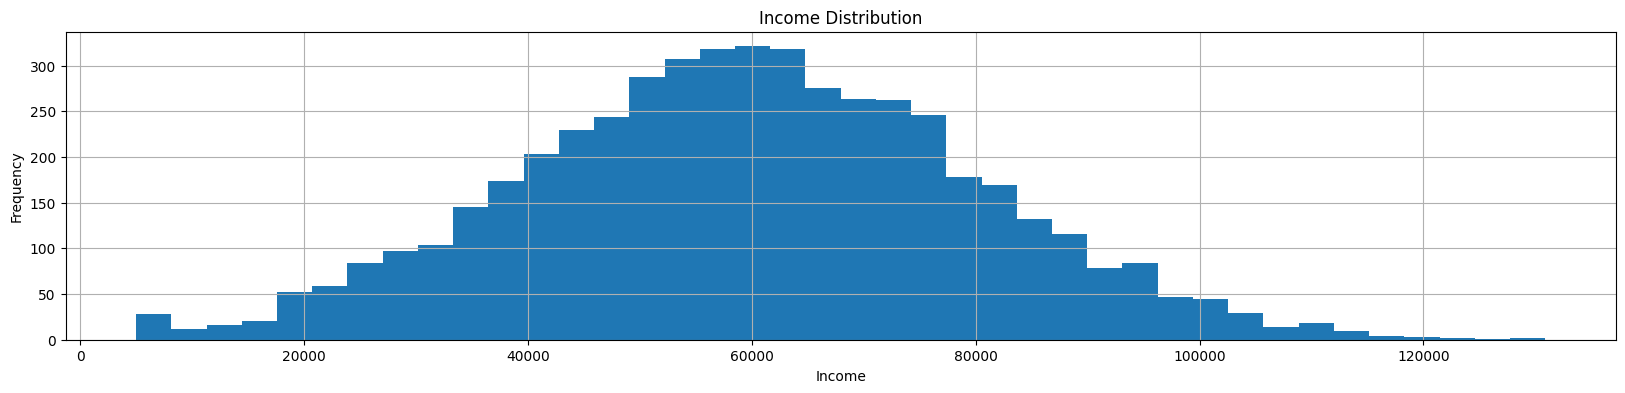

In [ ]:
plt.figure(figsize=(20,4))
plt.hist(customers["income"], bins=40)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


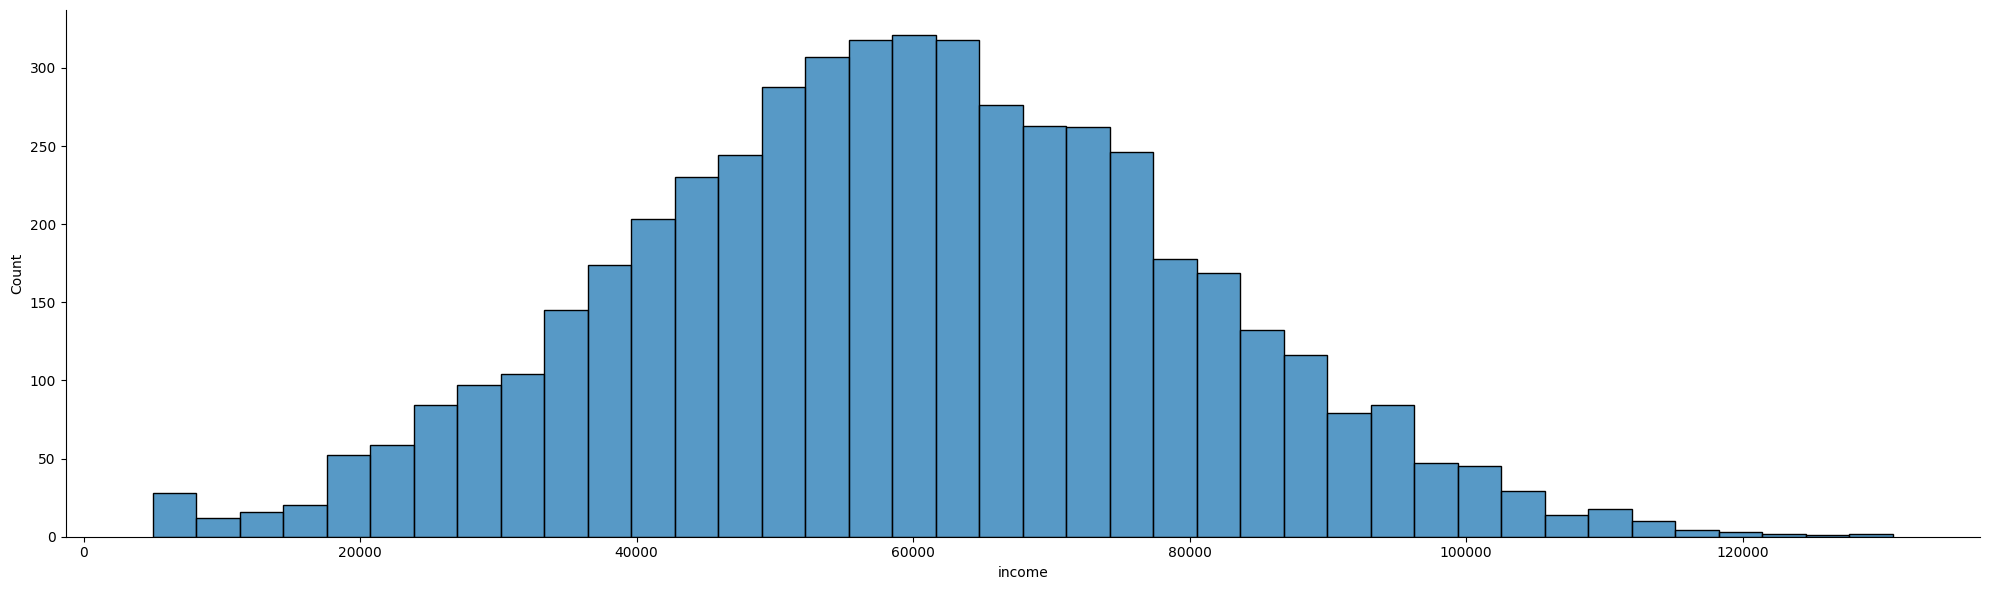

In [ ]:
import seaborn as sns
sns.displot(customers['income'], height=6, aspect=20/6)

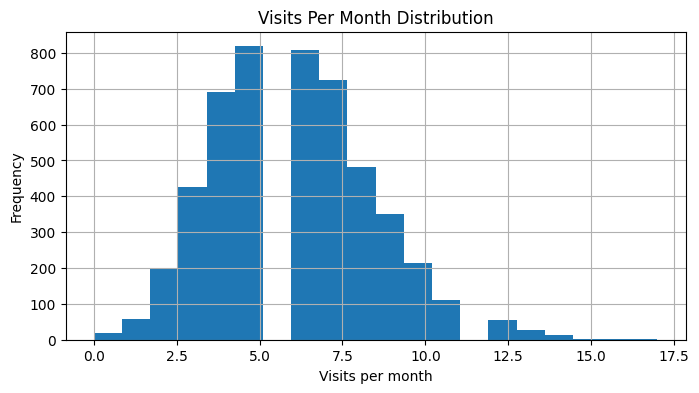

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(customers["visits_per_month"], bins=20)
plt.title("Visits Per Month Distribution")
plt.xlabel("Visits per month")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

🛒 Generate Transaction Data (Orders)

To replicate real-world e-commerce activity, we simulate 40,000 transaction records with realistic behavioral patterns.

📦 Transaction-Level Features

📅 order_date
Distributed across the 2023 calendar year to reflect seasonality and purchasing frequency

💳 order_amount
Generated using a Gamma distribution to model realistic right-skewed spending behavior
(Most orders are moderate, few are very large — typical in retail data)

🎟️ discount_used (0/1)
Binary indicator representing promotional or coupon usage

🔄 Customer-Level Aggregation

After generating transaction-level data, we transform it into customer-level features for modeling.

📊 Aggregated Features

📦 total_orders → Total number of purchases per customer

💰 total_spend → Cumulative spend across all transactions

📉 avg_order → Average order value (AOV)

🎟️ discount_rate → Percentage of orders using discounts

🧠 Why This Matters

✔️ Mimics real production ETL pipelines
✔️ Demonstrates feature engineering from raw transactional logs
✔️ Captures customer purchasing behavior
✔️ Provides inputs for segmentation, churn prediction, and spend forecasting

🏢 Case Study Note:
In a real company, this step would be implemented via SQL aggregation or data warehouse pipelines (e.g., Snowflake, BigQuery) before being consumed by downstream ML models.

In [ ]:
# =========================
# 2) GENERATE TRANSACTIONS
# =========================
n_transactions = 40000

transactions = pd.DataFrame({
    "transaction_id": range(1, n_transactions + 1),
    "customer_id": np.random.choice(customers["customer_id"], size=n_transactions),
    "order_date": pd.to_datetime("2023-01-01") + pd.to_timedelta(
        np.random.randint(0, 365, size=n_transactions), unit="D"
    ),
    "order_amount": np.random.gamma(shape=4, scale=20, size=n_transactions).round(2),
    "discount_used": np.random.choice([0, 1], size=n_transactions, p=[0.7, 0.3])
})

transactions.head()


,transaction_id,customer_id,order_date,order_amount,discount_used
0,1,2174,2023-03-01,60.76,0
1,2,4604,2023-11-17,85.44,0
2,3,2423,2023-06-01,38.42,1
3,4,4630,2023-03-10,94.81,0
4,5,4247,2023-02-04,47.56,0


In [ ]:
# =========================
# 3) AGGREGATE TRANSACTIONS TO CUSTOMER LEVEL
# =========================
customer_orders = transactions.groupby("customer_id").agg(
    total_orders =("transaction_id", "count"),
    total_spend =("order_amount", "sum"),
    avg_order =("order_amount", "mean"),
    discount_rate =("discount_used", "mean")
).reset_index()

customer_orders.head()

,customer_id,total_orders,total_spend,avg_order,discount_rate
0,1,7,883.27,126.181429,0.285714
1,2,13,1224.93,94.225385,0.230769
2,3,7,513.01,73.287143,0.142857
3,4,11,999.45,90.859091,0.272727
4,5,8,751.38,93.922500,0.625000


In [ ]:
#Merge Customers + Orders
customer_data = customers.merge(customer_orders, on="customer_id", how="left")
customer_data.fillna(0, inplace=True)  # customers with no orders -> 0s

customer_data.head()


,customer_id,country,age,income,tenure,visits_per_month,total_orders,total_spend,avg_order,discount_rate
0,1,US,68,59733.0,40,4,7.0,883.27,126.181429,0.285714
1,2,UK,57,53146.0,21,8,13.0,1224.93,94.225385,0.230769
2,3,UK,24,48007.0,46,2,7.0,513.01,73.287143,0.142857
3,4,US,49,20719.0,48,2,11.0,999.45,90.859091,0.272727
4,5,US,65,25343.0,38,5,8.0,751.38,93.922500,0.625000


🎯 Create Target Variables (What We Predict)

To mirror real-world modeling workflows, we generate business-relevant target variables for both classification and regression tasks.

🔹 Target 1: Churn Prediction (Classification)

We simulate churn probability using realistic behavioral assumptions commonly observed in subscription businesses:

📉 Behavioral Assumptions

⏳ Higher Tenure → Lower Churn
Long-standing customers are typically more loyal

💰 Higher Spend → Lower Churn
Customers who spend more tend to have higher engagement and lifetime value

📱 More Visits → Lower Churn
Frequent platform engagement signals retention strength

Using these signals, we generate probabilistic churn outcomes to reflect real customer behavior patterns.

🔹 Target 2: Next-Month Spend (Regression)

We simulate next-month revenue using behavior-driven logic:

💡 Spend Simulation Logic

🛒 avg_order × visits_per_month
Captures purchasing intensity and engagement

🎲 Noise Term
Introduces real-world randomness (seasonality, promotions, external factors)

🚫 Churned Customers → Spend ≈ 0
Customers who churn are assumed to stop spending

🧠 Why This Design Is Realistic

✔️ Reflects retention economics
✔️ Encodes behavioral causality
✔️ Enables both classification and regression modeling
✔️ Maintains consistency with real subscription business dynamics

🏢 Case Study Note:
In a production environment, churn labels are derived from subscription cancellations, billing failures, or defined inactivity thresholds. Revenue targets would be based on actual transaction logs with proper time-based feature separation to avoid data leakage.

In [ ]:
#Generate Churn +Next month Spend

# =========================
# 4) SIMULATE CHURN + NEXT MONTH SPEND
# =========================

# churn probability model (simulated)
prob_churn = (
    0.30
    - 0.003 * customer_data["tenure"]
    - 0.00001 * customer_data["total_spend"]
    - 0.02 * customer_data["visits_per_month"]
)

prob_churn = np.clip(prob_churn, 0.05, 0.80)

customer_data["churn"] = np.random.binomial(1, prob_churn)

# next month spend (simulated)
base_spend = 0.4 * customer_data["avg_order"] * customer_data["visits_per_month"]
noise = np.random.normal(0, 50, len(customer_data))

customer_data["next_month_spend"] = (base_spend + noise).round(2).clip(lower=0)

# churned customers spend ~ 0
customer_data["next_month_spend"] *= (1 - customer_data["churn"])

customer_data[["churn", "next_month_spend"]].head()

,churn,next_month_spend
0,0,229.53
1,0,277.36
2,1,0.00
3,0,19.28
4,0,188.91


🔷 Part A — Customer Segmentation (Unsupervised Learning)
🎯 Goal

Identify meaningful customer segments based on behavioral and transactional patterns to enable targeted marketing strategies, personalized offers, and differentiated retention campaigns.

Instead of treating all customers equally, we group them into data-driven clusters.

🧠 Methodology

We apply an unsupervised learning workflow commonly used in real production analytics pipelines:

1️⃣ Feature Scaling

📏 Standardize numeric features to ensure equal weighting

Prevent high-magnitude variables (e.g., total_spend) from dominating clustering

2️⃣ PCA (Principal Component Analysis)

📉 Reduce dimensionality to 2D for visualization

Remove correlated noise

Improve cluster separation clarity

Enable intuitive business interpretation

3️⃣ KMeans Clustering

🔵 Identify natural customer groupings

Minimize within-cluster variance

Assign each customer to a segment

4️⃣ Segment Profiling

📊 Compute average feature values per cluster

Compare spending, engagement, tenure, and discount behavior

Translate technical clusters into business personas

📈 Business Impact

✔️ Enables targeted marketing instead of blanket campaigns
✔️ Identifies high-value vs. price-sensitive customers
✔️ Supports churn-risk segment analysis
✔️ Improves campaign ROI and personalization

🏢 Case Study Note:
In real-world deployments, segmentation would be refreshed periodically (e.g., monthly) and integrated into CRM systems for automated targeting and experimentation.

In [ ]:
#pca +kmeans
# =========================
# 5) SEGMENTATION FEATURES
# =========================
seg_features = [
    "income", "tenure", "visits_per_month",
    "total_orders", "total_spend", "avg_order", "discount_rate"
]

X_seg = customer_data[seg_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_seg)

# PCA (reduce to 2 components for plotting)
pca = PCA(n_components=2, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

print("Explained variance by PC1+PC2:", pca.explained_variance_ratio_.sum().round(3))


Explained variance by PC1+PC2: 0.432


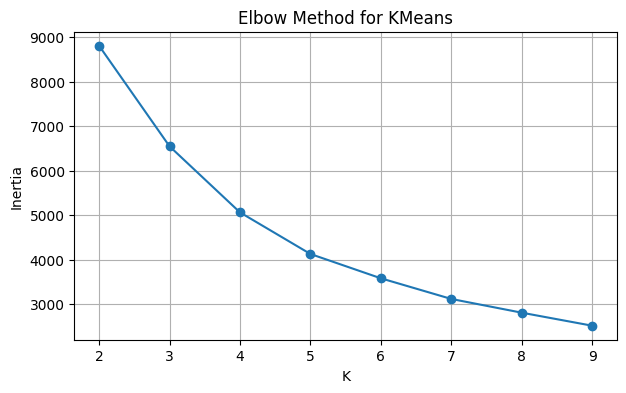

In [ ]:
# Elbow method
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_reduced)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(k_range), inertia, marker="o")
plt.title("Elbow Method for KMeans")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

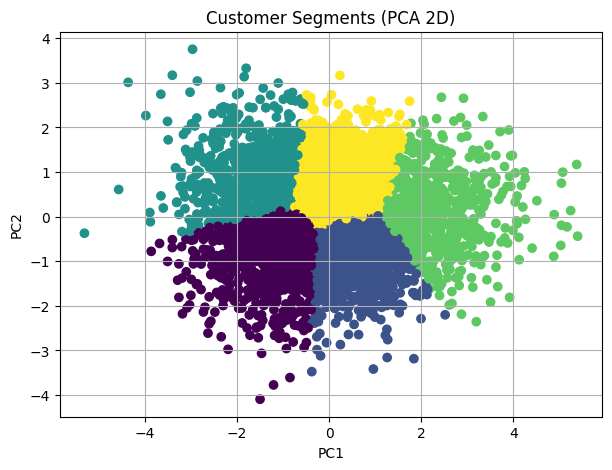

,income,tenure,visits_per_month,total_orders,total_spend,avg_order,discount_rate
segment,,,,,,,
0,64122.41,38.05,5.73,5.58,424.90,77.97,0.19
1,65541.16,40.24,5.50,8.66,742.11,87.54,0.22
2,55146.38,22.07,6.69,5.29,355.57,68.10,0.41
3,59385.78,28.76,5.94,12.27,1053.01,86.77,0.32
4,54790.23,20.63,6.34,8.71,676.17,78.99,0.38


In [ ]:
#(Train KMeans + Segment Profiles)
# Pick K (example: 5)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
customer_data["segment"] = kmeans.fit_predict(X_reduced)

# Plot segments
plt.figure(figsize=(7,5))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=customer_data["segment"])
plt.title("Customer Segments (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# Segment profiling
segment_profile = customer_data.groupby("segment")[seg_features].mean().round(2)
segment_profile


📊 Segment Insights (Business Interpretation Template)

Once the segment_profile table is generated, this section translates technical clusters into actionable business insights.

The goal is to convert numeric averages into clear customer personas and strategy recommendations.

🧠 How to Interpret the Segments

Review the average values for:

💰 Total Spend

📦 Total Orders

📉 Average Order Value

🎟️ Discount Rate

⏳ Tenure

📱 Visits per Month

Then classify each segment based on behavioral patterns.

📝 Example Interpretation Style

Use a concise, business-oriented format like this:

Segment 0: High spend, long tenure
→ 🏆 VIP customers
→ Strategy: Loyalty rewards, exclusive access, early product launches

Segment 1: Low tenure, low visits
→ ⚠️ At-risk / early-stage churn candidates
→ Strategy: Onboarding campaign, engagement emails, welcome discounts

Segment 2: Discount-heavy shoppers
→ 🎯 Price-sensitive segment
→ Strategy: Targeted promotions with margin control and frequency caps

🎯 Best Practice for Case Studies

✔️ Avoid only describing numbers
✔️ Translate clusters into customer personas
✔️ Connect each segment to a revenue or retention action
✔️ Think like a marketing or growth team

🏢 Case Study Note:
In a real company, these segments would be pushed into CRM systems (e.g., Salesforce, HubSpot) to automate campaign targeting and performance tracking.

# Part B — Churn Prediction (Classification)

## Goal
Predict which customers will churn so we can intervene early.

## Why accuracy is not enough
Churn can be imbalanced. We track:
- Precision (how many predicted churners are true churners)
- Recall (how many churners we caught)
- F1 score (balance of precision/recall)
- ROC-AUC (ranking quality)


In [ ]:
#(Train/Test + Logistic Regression)
# =========================
# 6) CHURN MODELING
# =========================
clf_features = [
    "tenure", "visits_per_month", "total_orders",
    "total_spend", "avg_order", "discount_rate", "income"
]

X = customer_data[clf_features]
y = customer_data["churn"]

print("Churn rate:", round(y.mean(),3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Scale for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

def clf_report(y_true, y_pred, y_proba, name="Model"):
    print(f"\n===== {name} =====")
    print("Accuracy :", (accuracy_score(y_true, y_pred)),3)
    print("Precision:", precision_score(y_true, y_pred),3)
    print("Recall   :", recall_score(y_true, y_pred),3)
    print("F1       :", f1_score(y_true, y_pred),3)
    print("ROC-AUC  :", roc_auc_score(y_true, y_proba),3)
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

clf_report(y_test, log_pred, log_proba, "Logistic Regression")


Churn rate: 0.097

===== Logistic Regression =====
Accuracy : 0.9032 3
Precision: 0.0 3
Recall   : 0.0 3
F1       : 0.0 3
ROC-AUC  : 0.6696776932705751 3
Confusion matrix:
 [[1129    0]
 [ 121    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#RandomForest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"  # helps with imbalance
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

clf_report(y_test, rf_pred, rf_proba, "Random Forest")



===== Random Forest =====
Accuracy : 0.9032 3
Precision: 0.0 3
Recall   : 0.0 3
F1       : 0.0 3
ROC-AUC  : 0.6089459698848538 3
Confusion matrix:
 [[1129    0]
 [ 121    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Churn Action
## Business actions from churn model
After scoring customers, a company can:

- High churn probability + high spend → **save with retention offer**
- High churn probability + low spend → **light-touch email + onboarding**
- Medium churn probability → **engagement nudges (content, push notifications)**

> Case-study note: In real production, you'd pick a threshold based on cost-benefit (cost of offer vs expected saved revenue).

## Spend Prediction
# Part C — Next-Month Spend Prediction (Regression)

## Goal
Forecast next month spend to:
- plan revenue
- personalize offers
- identify high-value customers early

We evaluate using:
- MAE (average absolute error)
- RMSE (penalizes big errors)
- R² (variance explained)

In [ ]:
#Regression Model
reg_features = [
    "income", "tenure", "visits_per_month",
    "total_orders", "total_spend", "avg_order",
    "discount_rate", "churn"
]

X = customer_data[reg_features]
y = customer_data["next_month_spend"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Baseline: simple linear regression using only total_spend
slr = LinearRegression()
slr.fit(X_train[["total_spend"]], y_train)
slr_pred = slr.predict(X_test[["total_spend"]])

print("=== Baseline (total_spend only) ===")
print("R2  :", round(r2_score(y_test, slr_pred),3))
print("MAE :", round(mean_absolute_error(y_test, slr_pred),3))
print("RMSE:", round(rmse(y_test, slr_pred),3))

# Multivariate linear regression
mlr = LinearRegression()
mlr.fit(X_train, y_train)
mlr_pred = mlr.predict(X_test)

print("\n=== Multivariate Linear Regression ===")
print("R2  :", round(r2_score(y_test, mlr_pred),3))
print("MAE :", round(mean_absolute_error(y_test, mlr_pred),3))
print("RMSE:", round(rmse(y_test, mlr_pred),3))


=== Baseline (total_spend only) ===
R2  : 0.024
MAE : 88.792
RMSE: 110.115

=== Multivariate Linear Regression ===
R2  : 0.753
MAE : 43.518
RMSE: 55.332


# Results Summary (write after you run metrics)

## What worked
- Segmentation revealed clear behavioral groups useful for targeted campaigns
- Churn model provided a ranking signal to prioritize retention
- Regression improved when using multiple behavioral features vs baseline

## Risks / limitations
- Data is simulated (real data will include missingness, seasonality, and leakage risks)
- No threshold optimization based on business cost
- No hyperparameter tuning / cross-validation

## Next steps (real-company upgrades)
- Use cross-validation + hyperparameter tuning
- Add calibration + threshold selection using ROI
- Add time-based split (train on past → test on future)
- Deploy pipeline: feature store + model monitoring + drift checks
